# 01. Benchmark моделей и двух стратегий

Сравниваются Logistic Regression, CatBoost, Random Forest, SVM, KNN и Gaussian Naive Bayes. `per_corridor` обучает отдельную модель на каждый коридор; `pooled_with_corridor_thresholds` обучает общую модель и калибрует порог отдельно по коридорам. Все результаты ниже получены только на внешних walk-forward test-периодах.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
RUN = ROOT / 'results/experiments/20260904_model_benchmark'
summary = pd.read_csv(RUN / 'summary.csv')
folds = pd.read_csv(RUN / 'fold_metrics.csv')

In [2]:
ranking = (summary.groupby(['strategy', 'model'], as_index=False)
           .agg(mean_lift=('lift', 'mean'), worst_fold=('min_fold_lift', 'min'),
                hit_rate=('signal_hit_rate', 'mean'), pr_auc=('pr_auc', 'mean'),
                roc_auc=('roc_auc', 'mean'), brier=('brier', 'mean'),
                signals_per_week=('signals_per_week', 'mean'))
           .sort_values(['mean_lift', 'worst_fold'], ascending=False))
display(ranking.style.format({c: '{:.3f}' for c in ranking.columns if c not in ['strategy','model']}))

,strategy,model,mean_lift,worst_fold,hit_rate,pr_auc,roc_auc,brier,signals_per_week
10,pooled_with_corridor_thresholds,random_forest,1.418,1.110,0.854,0.777,0.632,0.246,0.434
0,per_corridor,catboost,1.365,0.000,0.810,0.756,0.620,0.226,0.460
6,pooled_with_corridor_thresholds,catboost,1.341,0.932,0.815,0.756,0.633,0.221,0.498
4,per_corridor,random_forest,1.321,0.759,0.809,0.763,0.616,0.248,0.478
2,per_corridor,logistic,1.302,0.819,0.800,0.767,0.623,0.239,0.656
8,pooled_with_corridor_thresholds,logistic,1.289,0.901,0.794,0.771,0.628,0.238,0.694
1,per_corridor,knn,1.284,1.000,0.771,0.749,0.602,0.222,0.469
11,pooled_with_corridor_thresholds,svm,1.276,0.910,0.790,0.772,0.622,0.222,0.656
7,pooled_with_corridor_thresholds,knn,1.275,0.937,0.770,0.742,0.603,0.228,0.477
5,per_corridor,svm,1.263,0.822,0.775,0.773,0.622,0.216,0.608


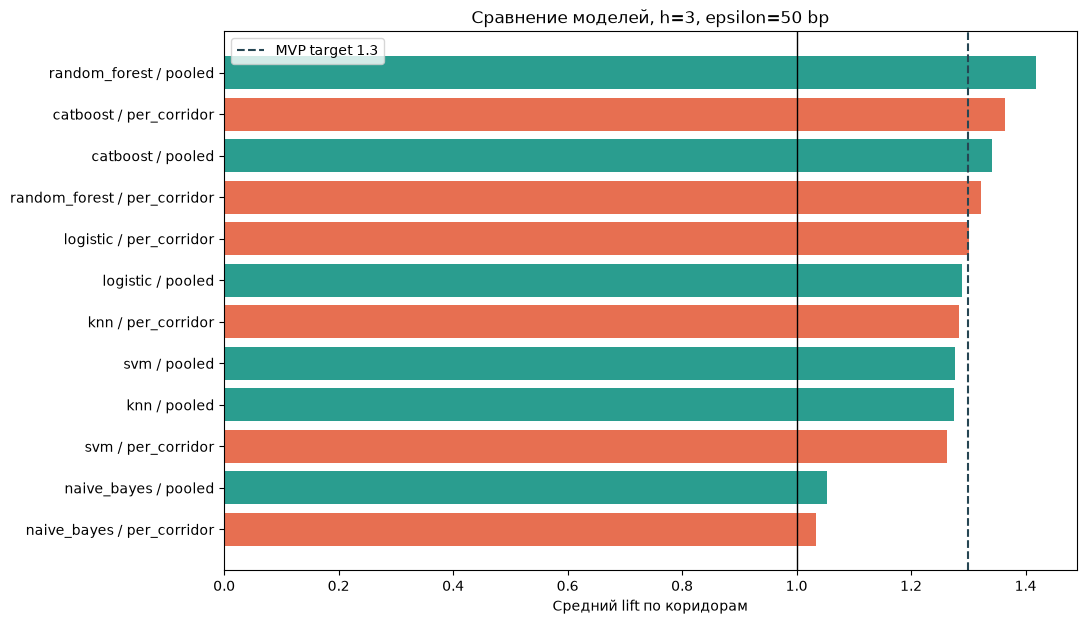

In [3]:
plot = ranking.sort_values('mean_lift')
labels = plot['model'] + ' / ' + plot['strategy'].str.replace('pooled_with_corridor_thresholds', 'pooled')
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(labels, plot['mean_lift'], color=['#E76F51' if x == 'per_corridor' else '#2A9D8F' for x in plot['strategy']])
ax.axvline(1.0, color='black', lw=1)
ax.axvline(1.3, color='#264653', ls='--', label='MVP target 1.3')
ax.set_xlabel('Средний lift по коридорам')
ax.set_title('Сравнение моделей, h=3, epsilon=50 bp')
ax.legend()
plt.show()

## Как читать метрики

Главная продуктовая метрика — lift к случайному расписанию с тем же числом сигналов и cooldown. Hit rate показывает правдивость пуша. PR-AUC и ROC-AUC проверяют ранжирование до выбора порога, Brier score — качество вероятностного score, balanced accuracy — качество обоих классов. Частота и false push rate являются proxy продуктового давления, но не прямой мерой лояльности.

In [4]:
best = ranking.iloc[0]
print(f"Лидер по среднему lift: {best.model} / {best.strategy}: {best.mean_lift:.2f}")
display(summary[(summary['model'] == best.model) & (summary['strategy'] == best.strategy)].sort_values('lift', ascending=False))

Лидер по среднему lift: random_forest / pooled_with_corridor_thresholds: 1.42


,hypothesis_id,horizon_days,epsilon_bps,strategy,model,corridor,folds,signals,signals_per_week,signal_hit_rate,...,min_fold_lift,folds_lift_ge_1_3,roc_auc,pr_auc,brier,balanced_accuracy,mean_advantage_bps,mean_regret_bps,client_advantage_rub_mean,client_regret_rub_mean
31,H007_add_usd_eur,3,50,pooled_with_corridor_thresholds,random_forest,RUB_KGS,5,104,0.442553,0.875000,...,1.155568,4,0.642829,0.788239,0.245030,0.563008,13.951385,18.941677,139.513849,189.416767
32,H007_add_usd_eur,3,50,pooled_with_corridor_thresholds,random_forest,RUB_AMD,5,96,0.408511,0.885417,...,1.130631,3,0.624498,0.778130,0.249147,0.554614,11.824080,15.293869,118.240801,152.938689
33,H007_add_usd_eur,3,50,pooled_with_corridor_thresholds,random_forest,RUB_TJS,4,95,0.515105,0.884211,...,1.212541,3,0.630136,0.808176,0.245286,0.565798,11.846772,17.512714,118.467718,175.127139
35,H007_add_usd_eur,3,50,pooled_with_corridor_thresholds,random_forest,RUB_KZT,5,72,0.306383,0.819444,...,1.161890,4,0.620030,0.726995,0.249207,0.538946,15.627251,20.318360,156.272511,203.183596
44,H007_add_usd_eur,3,50,pooled_with_corridor_thresholds,random_forest,RUB_UZS,4,92,0.498838,0.804348,...,1.109755,2,0.642179,0.781731,0.243682,0.570730,14.046391,24.436734,140.463909,244.367337
